# Regime-Based Hedging of the S&P 500 using Gold and U.S. Treasuries
## Objective

This project evaluates whether the optimal hedge for the S&P 500 varies across macroeconomic regimes defined by inflation and growth trends. The goal is to construct a dynamic allocation between equities, gold, and Treasuries that improves downside protection while maintaining competitive long-term returns.

**Key Finding:** The regime-based strategy reduces maximum drawdown from -52.6% (unhedged S&P 500) to -34.3% — an 18 percentage point improvement — while maintaining similar annualised returns (~8.3% net vs 8.8%).

## Research Question

Can a regime-conditioned hedge improve drawdown and risk-adjusted performance relative to both an unhedged equity portfolio and a static diversified allocation?

## Approach

- Define macro regimes using GDP and CPI trend dynamics  
- Construct monthly returns for S&P 500, gold, and a Treasury proxy  
- Use a rolling walk-forward framework with a 60-month lookback  
- Solve a constrained portfolio optimisation problem within each regime  
- Evaluate out-of-sample performance with transaction costs  

In [ ]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Data

The analysis uses the provided dataset containing:

- GDP YoY and CPI YoY for macroeconomic conditions  
- S&P 500 and gold price series for asset returns  
- U.S. 10-year Treasury yield to approximate bond returns  

All data is resampled to month-end frequency to align macro signals with portfolio rebalancing decisions.

In [ ]:
# 1. LOAD DATA

file_path = "Data_260226.xlsx"

macro = pd.read_excel(file_path, sheet_name="Macro")
prices = pd.read_excel(file_path, sheet_name="Prices")
yields = pd.read_excel(file_path, sheet_name="Yield")

macro["Date"] = pd.to_datetime(macro["Date"])
prices["Date"] = pd.to_datetime(prices["Date"])
yields["Date"] = pd.to_datetime(yields["Date"])

macro = macro.sort_values("Date").set_index("Date")
prices = prices.sort_values("Date").set_index("Date")
yields = yields.sort_values("Date").set_index("Date")

print("Macro shape:", macro.shape)
print("Prices shape:", prices.shape)
print("Yields shape:", yields.shape)

Macro shape: (661, 2)
Prices shape: (14288, 3)
Yields shape: (14141, 1)


## Data Preparation

The data is resampled to month-end frequency so that macroeconomic signals and portfolio returns are aligned at a common monthly decision horizon.

The final incomplete month is excluded to avoid contaminating monthly returns with partial-period observations.

In [ ]:
# 2. RESAMPLE TO MONTH-END

last_date = prices.index.max()
last_complete_month = last_date.to_period("M").to_timestamp("M")

if last_date < last_complete_month:
    last_complete_month = (last_date - pd.offsets.MonthEnd(1)).to_period("M").to_timestamp("M")

macro_m = macro.resample("ME").last().loc[:last_complete_month]
prices_m = prices.resample("ME").last().loc[:last_complete_month]
yields_m = yields.resample("ME").last().loc[:last_complete_month]

macro_m["GDP YOY"] = macro_m["GDP YOY"].ffill()
macro_m["CPI YOY"] = macro_m["CPI YOY"].ffill()

print("Last complete month used:", last_complete_month.date())
print("Monthly observations:")
print("Macro:", len(macro_m))
print("Prices:", len(prices_m))
print("Yields:", len(yields_m))

Last complete month used: 2026-01-31
Monthly observations:
Macro: 662
Prices: 662
Yields: 662


## Treasury Return Approximation

The dataset provides the 10-year Treasury yield rather than a total return index. Monthly bond returns are therefore approximated using a constant-duration model:

Bond return ≈ carry + price effect

- Carry is approximated as the lagged yield divided by 12  
- Price changes are modeled using duration multiplied by yield changes  

This captures the primary drivers of bond returns but ignores convexity and yield curve dynamics, meaning it may deviate from the performance of a real bond portfolio or ETF.

In [ ]:
# 3. COMPUTE MONTHLY RETURNS

rets = pd.DataFrame(index=prices_m.index)
rets["spx_ret"] = prices_m["S&P 500"].pct_change(fill_method=None)
rets["gold_ret"] = prices_m["Gold"].pct_change(fill_method=None)

# Treasury return approximation
duration = 8.0

bond = pd.DataFrame(index=yields_m.index)
bond["yield"] = yields_m["US 10YR Bonds"]
bond["dy"] = bond["yield"].diff()

# Approximate monthly Treasury return:
# carry + price effect
bond["bond_ret"] = (bond["yield"].shift(1) / 100) / 12 - duration * (bond["dy"] / 100)

rets = rets.join(bond["bond_ret"], how="inner")

rets.head()

,spx_ret,gold_ret,bond_ret
Date,,,
1970-12-31,NaN,NaN,NaN
1971-01-31,0.040477,0.011485,0.038218
1971-02-28,0.009074,0.022973,0.001077
1971-03-31,0.036796,0.003356,0.053918
1971-04-30,0.036288,0.003602,-0.039390


## Regime Construction

Economic regimes are defined using the direction of change in growth and inflation:

- Goldilocks: rising growth, falling inflation  
- Overheating: rising growth, rising inflation  
- Stagflation: falling growth, rising inflation  
- Slowdown: falling growth, falling inflation  

To reduce look-ahead bias, macro signals are lagged:

- CPI is lagged by 1 month  
- GDP is lagged by 3 months  

GDP trends are computed over a 3-month window to reflect its quarterly nature.

In [ ]:
# 4. DEFINE ECONOMIC REGIMES

reg = macro_m[["GDP YOY", "CPI YOY"]].copy()

# Conservative publication-lag assumptions
reg["GDP_YOY_signal"] = reg["GDP YOY"].ffill().shift(3)
reg["CPI_YOY_signal"] = reg["CPI YOY"].ffill().shift(1)

# GDP is quarterly in nature, so use 3-month change
reg["gdp_trend"] = reg["GDP_YOY_signal"].diff(3)
reg["cpi_trend"] = reg["CPI_YOY_signal"].diff(1)

reg = reg.dropna(subset=["gdp_trend", "cpi_trend"])

reg["growth_dir"] = np.where(reg["gdp_trend"] >= 0, "RisingGrowth", "FallingGrowth")
reg["infl_dir"] = np.where(reg["cpi_trend"] >= 0, "RisingInflation", "FallingInflation")

def label_regime(row):
    if row["growth_dir"] == "RisingGrowth" and row["infl_dir"] == "FallingInflation":
        return "Goldilocks"
    elif row["growth_dir"] == "RisingGrowth" and row["infl_dir"] == "RisingInflation":
        return "Overheating"
    elif row["growth_dir"] == "FallingGrowth" and row["infl_dir"] == "RisingInflation":
        return "Stagflation"
    else:
        return "Slowdown"

reg["regime"] = reg.apply(label_regime, axis=1)
reg["regime_lag"] = reg["regime"].shift(1)

reg[["GDP YOY", "CPI YOY", "gdp_trend", "cpi_trend", "regime", "regime_lag"]].tail()

,GDP YOY,CPI YOY,gdp_trend,cpi_trend,regime,regime_lag
Date,,,,,,
2025-09-30,2.3,3.0,0.1,0.2,Overheating,Stagflation
2025-10-31,2.3,3.0,0.1,0.1,Overheating,Overheating
2025-11-30,2.3,2.7,0.1,0.0,Overheating,Overheating
2025-12-31,2.2,2.7,0.2,-0.3,Goldilocks,Overheating
2026-01-31,2.2,2.4,0.2,0.0,Overheating,Goldilocks


## Merge Macro and Asset Data

The return series and lagged macro regime labels are merged into a single monthly dataset. The lagged regime is used for allocation decisions to ensure that the strategy does not rely on future macro information.

In [ ]:
# 5. MERGE RETURNS + REGIMES

df = rets.join(reg[["regime_lag"]], how="inner").dropna()
df = df.rename(columns={"regime_lag": "regime"})

print("Merged sample starts:", df.index.min())
print("Merged sample ends:", df.index.max())
print("Observations:", len(df))

df.head()

Merged sample starts: 1971-07-31 00:00:00
Merged sample ends: 2026-01-31 00:00:00
Observations: 655


,spx_ret,gold_ret,bond_ret,regime
Date,,,,
1971-07-31,-0.041324,0.021197,-0.006415,Overheating
1971-08-31,0.036095,0.043468,0.051310,Overheating
1971-09-30,-0.006968,-0.016616,0.027635,Goldilocks
1971-10-31,-0.041794,0.011423,0.015402,Overheating
1971-11-30,-0.002547,0.008471,0.000093,Goldilocks


## Performance Functions

The backtest is evaluated using annualized return, annualized volatility, Sortino ratio, and maximum drawdown.

These metrics are used to assess both return generation and downside protection.

In [ ]:
# 6. PERFORMANCE FUNCTIONS

def ann_return(r, periods=12):
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    total = (1 + r).prod()
    years = len(r) / periods
    return total ** (1 / years) - 1 if years > 0 else np.nan

def ann_vol(r, periods=12):
    r = r.dropna()
    if len(r) < 2:
        return np.nan
    return r.std() * np.sqrt(periods)

def max_drawdown(r):
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1
    return dd.min()

def sortino(r, periods=12):
    r = r.dropna()
    if len(r) < 2:
        return np.nan
    downside = r[r < 0]
    if len(downside) < 2 or downside.std() == 0:
        return np.nan
    return ann_return(r, periods) / (downside.std() * np.sqrt(periods))

## Regime-Conditional Portfolio Optimisation

For each regime, portfolio weights are determined using a constrained mean-variance optimisation:

Maximise:  
μ'w − λ w'Σw  

Subject to:

- Full investment: weights sum to 1  
- No shorting: weights ≥ 0  
- Hedge constraint: Gold + Bond ≤ 60%  

Where:

- μ represents expected returns  
- Σ represents the covariance matrix  
- λ is the risk-aversion parameter  

The risk-aversion parameter (λ = 3) is chosen to reflect a moderate balance between return-seeking and risk control. Since the objective of the strategy is to provide downside protection rather than purely maximize returns, a higher penalty is placed on variance to reduce drawdowns while still allowing meaningful exposure to equities.

The hedge constraint ensures that the combined allocation to gold and Treasuries does not exceed 60%, which enforces a minimum equity exposure of at least 40%. This is important because the strategy is designed as a hedging overlay rather than a full defensive allocation. Without this constraint, the optimiser could allocate excessively to defensive assets in certain regimes, undermining the core objective of maintaining equity participation while improving downside protection.

This framework replaces a heuristic search with a formal optimisation model and allows portfolio weights to adapt systematically across macro regimes.

In [ ]:
# 7. REGIME-CONDITIONAL OPTIMISER

def optimise_weights_regime(sub, risk_aversion=3.0, max_hedge=0.60):

    assets = ["spx_ret", "gold_ret", "bond_ret"]
    data = sub[assets].dropna()

    if len(data) < 12:
        return np.array([1.0, 0.0, 0.0])yes

    mu = data.mean().values
    cov = data.cov().values

    # Numerical stability
    cov = cov + 1e-6 * np.eye(3)

    def objective(w):
        port_ret = np.dot(mu, w)
        port_var = np.dot(w, cov @ w)
        return -(port_ret - risk_aversion * port_var)

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w: max_hedge - (w[1] + w[2])}
    ]

    bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]
    x0 = np.array([0.8, 0.1, 0.1])

    result = minimize(
        objective,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        return result.x
    else:
        return np.array([1.0, 0.0, 0.0])

## Walk-Forward Backtest

A rolling out-of-sample framework is used to simulate real-time portfolio decisions.

At each month:

1. The previous 60 months are used as the training window  
2. The optimal portfolio weights are estimated separately for each regime  
3. The weights corresponding to the current (lagged) regime are applied to the next month  

This ensures that all allocation decisions are based strictly on historical information.

In [ ]:
# 8. WALK-FORWARD OUT-OF-SAMPLE BACKTEST

lookback = 60

oos_returns = []
dates = []
weights_list = []
chosen_regimes = []

for i in range(lookback, len(df)):

    if (i - lookback) % 12 == 0:
        print(f"Processing {i - lookback + 1} / {len(df) - lookback}")

    train = df.iloc[i - lookback:i].copy()
    test = df.iloc[i]

    regime_map = {}

    for regime_name in train["regime"].dropna().unique():
        sub = train[train["regime"] == regime_name].copy()

        if len(sub) < 12:
            continue

        w_opt = optimise_weights_regime(
            sub=sub,
            risk_aversion=3.0,
            max_hedge=0.60
        )

        regime_map[regime_name] = w_opt

    current_regime = test["regime"]

    if current_regime in regime_map:
        w_spx, w_gold, w_bond = regime_map[current_regime]
    else:
        w_spx, w_gold, w_bond = 1.0, 0.0, 0.0

    ret = (
        w_spx * test["spx_ret"]
        + w_gold * test["gold_ret"]
        + w_bond * test["bond_ret"]
    )

    oos_returns.append(ret)
    dates.append(test.name)
    weights_list.append([w_spx, w_gold, w_bond])
    chosen_regimes.append(current_regime)

print("Done.")

Processing 1 / 595
Processing 13 / 595
Processing 25 / 595
Processing 37 / 595
Processing 49 / 595
Processing 61 / 595
Processing 73 / 595
Processing 85 / 595
Processing 97 / 595
Processing 109 / 595
Processing 121 / 595
Processing 133 / 595
Processing 145 / 595
Processing 157 / 595
Processing 169 / 595
Processing 181 / 595
Processing 193 / 595
Processing 205 / 595
Processing 217 / 595
Processing 229 / 595
Processing 241 / 595
Processing 253 / 595
Processing 265 / 595
Processing 277 / 595
Processing 289 / 595
Processing 301 / 595
Processing 313 / 595
Processing 325 / 595
Processing 337 / 595
Processing 349 / 595
Processing 361 / 595
Processing 373 / 595
Processing 385 / 595
Processing 397 / 595
Processing 409 / 595
Processing 421 / 595
Processing 433 / 595
Processing 445 / 595
Processing 457 / 595
Processing 469 / 595
Processing 481 / 595
Processing 493 / 595
Processing 505 / 595
Processing 517 / 595
Processing 529 / 595
Processing 541 / 595
Processing 553 / 595
Processing 565 / 595
Pr

## Convert Outputs

The walk-forward engine produces:

- a monthly out-of-sample return series  
- a time series of portfolio weights  
- the macro regime associated with each month  

These outputs are then used for benchmarking, transaction cost analysis, and visualisation.

In [ ]:
# 9. CONVERT OUTPUTS

oos = pd.Series(oos_returns, index=dates, name="oos_gross")
weights_oos = pd.DataFrame(weights_list, index=dates, columns=["SPX", "Gold", "Bond"])
regime_oos = pd.Series(chosen_regimes, index=dates, name="regime")

print(len(oos), len(weights_oos), len(regime_oos))
weights_oos.head()

595 595 595


,SPX,Gold,Bond
1976-07-31,0.40000,6.000000e-01,0.00000
1976-08-31,0.40000,1.110223e-16,0.60000
1976-09-30,0.40000,2.775558e-17,0.60000
1976-10-31,0.40000,6.000000e-01,0.00000
1976-11-30,0.45412,0.000000e+00,0.54588


## Transaction Costs

Transaction costs are modeled as 10 basis points per unit of monthly portfolio turnover.

This allows the backtest to compare gross and net performance and quantify the implementation cost of dynamic allocation.

In [ ]:
# 10. TRANSACTION COSTS

tc = 0.001  # 10 bps per unit turnover

turnover = weights_oos.diff().abs().sum(axis=1).fillna(0)
cost = turnover * tc

oos_net = oos - cost

## Benchmark Comparison

The strategy is evaluated against:

- Unhedged S&P 500  
- Static diversified portfolio (80% equities, 10% gold, 10% Treasuries)  

This allows assessment of whether dynamic regime-based allocation adds value beyond simple diversification.

In [ ]:
# 11. BENCHMARKS

spx_oos = df.loc[oos.index, "spx_ret"]
gold_oos = df.loc[oos.index, "gold_ret"]
bond_oos = df.loc[oos.index, "bond_ret"]

static_hedge = 0.80 * spx_oos + 0.10 * gold_oos + 0.10 * bond_oos

summary = pd.DataFrame([
    {
        "Strategy": "SPX",
        "Ann Return": ann_return(spx_oos),
        "Ann Vol": ann_vol(spx_oos),
        "Sortino": sortino(spx_oos),
        "Max DD": max_drawdown(spx_oos)
    },
    {
        "Strategy": "Static 80/10/10",
        "Ann Return": ann_return(static_hedge),
        "Ann Vol": ann_vol(static_hedge),
        "Sortino": sortino(static_hedge),
        "Max DD": max_drawdown(static_hedge)
    },
    {
        "Strategy": "OOS Hedged (Gross)",
        "Ann Return": ann_return(oos),
        "Ann Vol": ann_vol(oos),
        "Sortino": sortino(oos),
        "Max DD": max_drawdown(oos)
    },
    {
        "Strategy": "OOS Hedged (Net)",
        "Ann Return": ann_return(oos_net),
        "Ann Vol": ann_vol(oos_net),
        "Sortino": sortino(oos_net),
        "Max DD": max_drawdown(oos_net)
    }
])



In [ ]:
print(summary.round(4))

             Strategy  Ann Return  Ann Vol  Sortino  Max DD
0                 SPX      0.0883   0.1493   0.8095 -0.5256
1     Static 80/10/10      0.0882   0.1230   1.0059 -0.4238
2  OOS Hedged (Gross)      0.0890   0.1326   0.8875 -0.3372
3    OOS Hedged (Net)      0.0826   0.1327   0.8256 -0.3430


## Key Results Summary

| Strategy | Return | Volatility | Sortino | Max Drawdown |
|----------|--------|------------|---------|--------------|
| SPX | 8.83% | 14.93% | 0.81 | -52.6% |
| Static 80/10/10 | 8.82% | 12.30% | 1.01 | -42.4% |
| Regime Hedged (Gross) | 8.90% | 13.26% | 0.89 | -33.7% |
| Regime Hedged (Net) | 8.26% | 13.27% | 0.83 | -34.3% |

**The regime strategy's primary value is drawdown reduction**, cutting worst-case losses by ~18 percentage points vs SPX and ~8 points vs the static allocation. The static 80/10/10 achieves a higher Sortino ratio because the fixed weights provide smoother diversification without the noise of monthly regime switching.


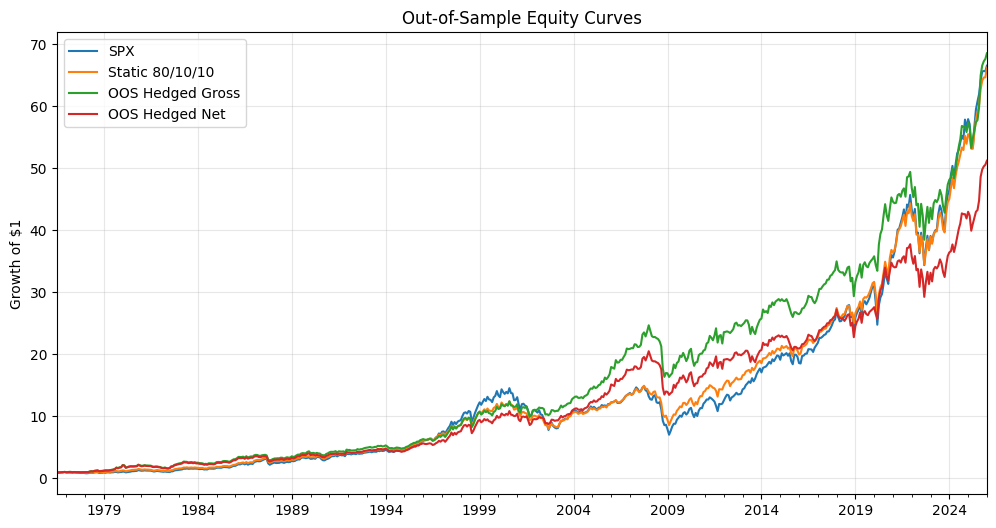

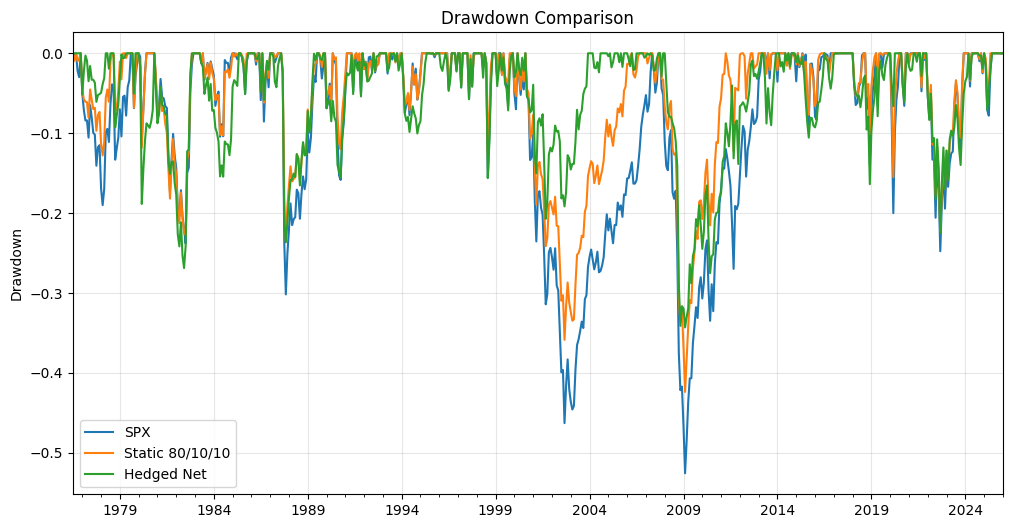

In [ ]:
# 12. EQUITY CURVES & DRAWDOWN COMPARISON

equity = pd.DataFrame({
    "SPX": (1 + spx_oos).cumprod(),
    "Static 80/10/10": (1 + static_hedge).cumprod(),
    "OOS Hedged Gross": (1 + oos).cumprod(),
    "OOS Hedged Net": (1 + oos_net).cumprod()
})

equity.plot(figsize=(12, 6), title="Out-of-Sample Equity Curves")
plt.ylabel("Growth of $1")
plt.grid(alpha=0.3)
plt.show()

def drawdown(series):
    wealth = (1 + series).cumprod()
    peak = wealth.cummax()
    return wealth / peak - 1

dd = pd.DataFrame({
    "SPX": drawdown(spx_oos),
    "Static 80/10/10": drawdown(static_hedge),
    "Hedged Net": drawdown(oos_net)
})

dd.plot(figsize=(12, 6), title="Drawdown Comparison")
plt.ylabel("Drawdown")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# 13. REGIME DISTRIBUTION

regime_counts = regime_oos.value_counts()
print(regime_counts)

regime
Overheating    177
Stagflation    163
Slowdown       140
Goldilocks     115
Name: count, dtype: int64


## Regime-Level Performance

This section breaks down performance by macro regime to identify where the hedge adds the most value and where it gives up upside.

In [ ]:
# 14. REGIME-LEVEL PERFORMANCE

regime_perf = []

for regime_name in regime_oos.dropna().unique():
    idx = regime_oos[regime_oos == regime_name].index

    spx_r = spx_oos.loc[idx]
    gross_r = oos.loc[idx]
    net_r = oos_net.loc[idx]

    regime_perf.append({
        "Regime": regime_name,
        "SPX Return": ann_return(spx_r),
        "SPX Vol": ann_vol(spx_r),
        "Gross Return": ann_return(gross_r),
        "Gross Vol": ann_vol(gross_r),
        "Gross Sortino": sortino(gross_r),
        "Net Return": ann_return(net_r),
        "Net Vol": ann_vol(net_r),
        "Net Sortino": sortino(net_r),
        "Months": len(idx)
    })

regime_perf_df = pd.DataFrame(regime_perf).sort_values("Regime")
print(regime_perf_df.round(4))

weights_by_regime = weights_oos.join(regime_oos).groupby("regime")[["SPX", "Gold", "Bond"]].mean()

print("\n" + "="*55)
print("OPTIMAL HEDGE WEIGHTS BY REGIME (Average)")
print("="*55)
print(weights_by_regime.round(3).to_string())
print("="*55)
print("Note: Gold + Bond capped at 60% by construction.")

        Regime  SPX Return  SPX Vol  Gross Return  Gross Vol  Gross Sortino  \
1   Goldilocks      0.0993   0.1444        0.0759     0.1336         0.6683   
0  Overheating      0.0077   0.1610        0.0067     0.1184         0.0611   
2     Slowdown      0.1812   0.1436        0.1652     0.1306         2.0553   
3  Stagflation      0.0951   0.1420        0.1288     0.1450         1.3308   

   Net Return  Net Vol  Net Sortino  Months  
1      0.0680   0.1336       0.5986     115  
0      0.0002   0.1183       0.0020     177  
2      0.1593   0.1306       1.9796     140  
3      0.1232   0.1450       1.2800     163  

OPTIMAL HEDGE WEIGHTS BY REGIME (Average)
               SPX   Gold   Bond
regime                          
Goldilocks   0.845  0.017  0.138
Overheating  0.491  0.241  0.269
Slowdown     0.715  0.242  0.043
Stagflation  0.625  0.166  0.209
Note: Gold + Bond capped at 60% by construction.


## Regime-Level Interpretation

- Goldilocks: The strategy gives up some upside relative to equities, reflecting the cost of hedging in pro-risk environments.  
- Overheating: The strategy improves stability through increased hedge exposure, although return improvements are limited.  
- Slowdown: The strategy preserves most of the equity upside while reducing volatility, resulting in strong downside-adjusted performance.  
- Stagflation: The strategy performs relatively well, suggesting that a mixed gold and bond hedge is beneficial when inflation remains elevated and growth weakens.

## Correlation Analysis

Correlation between equities, gold, and Treasuries varies across regimes.

Gold shows the most favorable diversification properties in overheating environments, where it exhibits negative correlation with equities. In other regimes, correlations are generally weak or slightly positive.

This suggests that the effectiveness of the hedge is not driven purely by static correlation, but by regime-dependent interactions between returns, volatility, and allocation.

In [ ]:
# 15. CORRELATION MATRIX BY REGIME

for regime_name in regime_oos.dropna().unique():
    sub = df.loc[regime_oos[regime_oos == regime_name].index, ["spx_ret", "gold_ret", "bond_ret"]]
    print(f"\n=== Correlation Matrix: {regime_name} | N={len(sub)} ===")
    print(sub.corr().round(3))


=== Correlation Matrix: Overheating | N=177 ===
          spx_ret  gold_ret  bond_ret
spx_ret     1.000    -0.158     0.067
gold_ret   -0.158     1.000    -0.040
bond_ret    0.067    -0.040     1.000

=== Correlation Matrix: Goldilocks | N=115 ===
          spx_ret  gold_ret  bond_ret
spx_ret     1.000     0.203     0.093
gold_ret    0.203     1.000     0.266
bond_ret    0.093     0.266     1.000

=== Correlation Matrix: Slowdown | N=140 ===
          spx_ret  gold_ret  bond_ret
spx_ret     1.000     0.013     0.180
gold_ret    0.013     1.000     0.099
bond_ret    0.180     0.099     1.000

=== Correlation Matrix: Stagflation | N=163 ===
          spx_ret  gold_ret  bond_ret
spx_ret     1.000     0.132     0.131
gold_ret    0.132     1.000     0.054
bond_ret    0.131     0.054     1.000


## Turnover and Implementation

The strategy exhibits moderate turnover due to monthly rebalancing and regime shifts.

Because the full monthly turnover series is visually noisy over a long sample, I summarize turnover using headline statistics rather than emphasizing the raw time-series plot. Transaction costs reduce gross performance meaningfully, highlighting the trade-off between responsiveness and implementation cost.

In [ ]:
# 16. TURNOVER ANALYSIS

avg_turnover = turnover.mean()
max_turnover = turnover.max()
annualized_turnover = avg_turnover * 12

print(f"Average monthly turnover: {avg_turnover:.4f}")
print(f"Max monthly turnover: {max_turnover:.4f}")
print(f"Annualized turnover: {annualized_turnover:.4f}")


Average monthly turnover: 0.4923
Max monthly turnover: 1.2000
Annualized turnover: 5.9073


## Smoothed Portfolio Allocation

The raw monthly allocation series is noisy because the strategy rebalances frequently. A 6-month rolling average makes the allocation pattern easier to interpret.

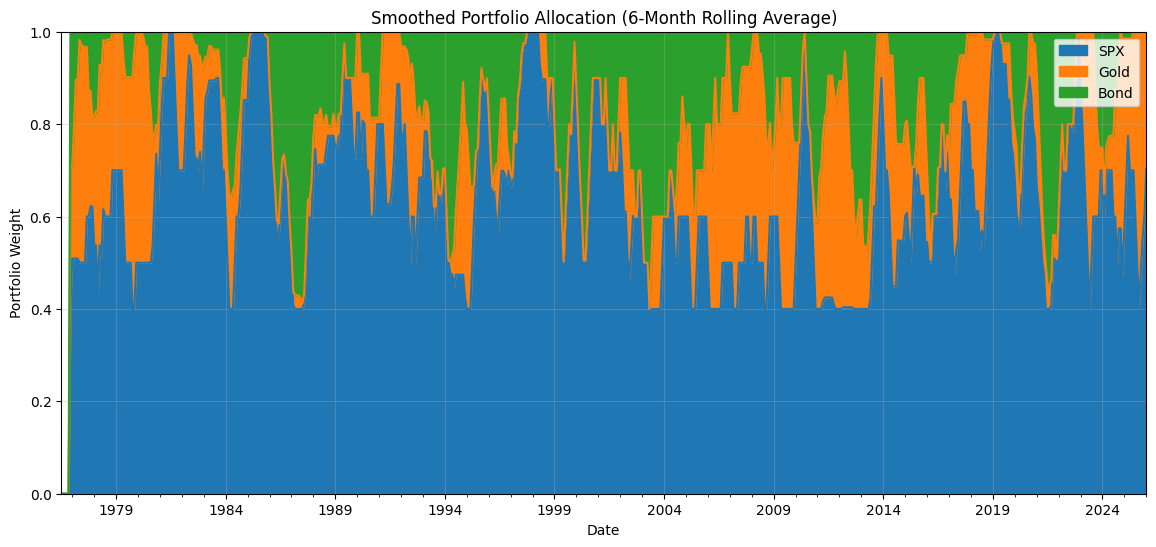

In [ ]:
# 17. SMOOTHED PORTFOLIO ALLOCATION

weights_smooth = weights_oos.rolling(6).mean()

weights_smooth.plot.area(figsize=(14, 6))
plt.title("Smoothed Portfolio Allocation (6-Month Rolling Average)")
plt.ylabel("Portfolio Weight")
plt.xlabel("Date")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend(loc="upper right")
plt.show()

## Allocation During Key Stress Periods

To better illustrate how the strategy responds to adverse market environments, I also focus on selected stress periods where equity drawdowns were significant.

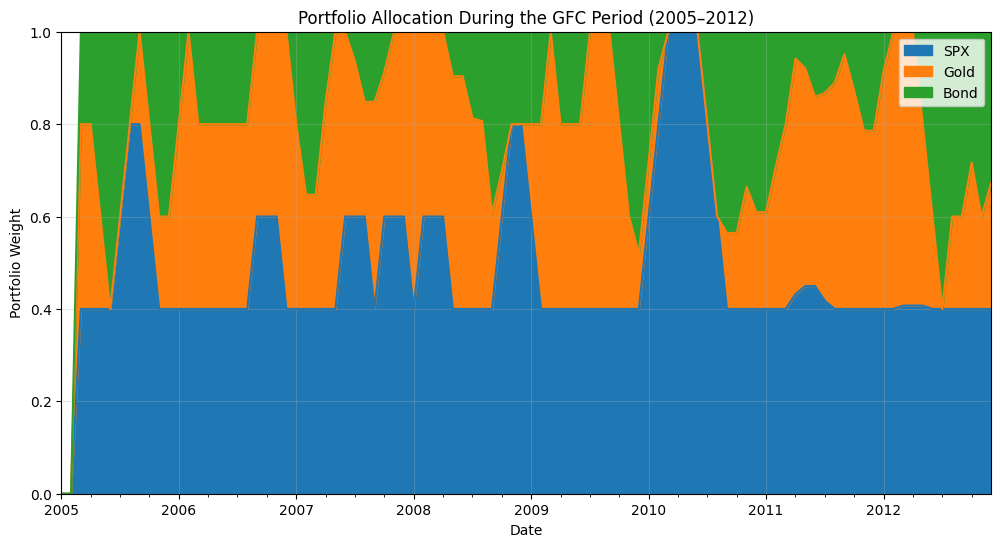

In [ ]:
# 17. ALLOCATION DURING GFC PERIOD

weights_gfc = weights_oos.loc["2005":"2012"].rolling(3).mean()

weights_gfc.plot.area(figsize=(12, 6))
plt.title("Portfolio Allocation During the GFC Period (2005–2012)")
plt.ylabel("Portfolio Weight")
plt.xlabel("Date")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend(loc="upper right")
plt.show()

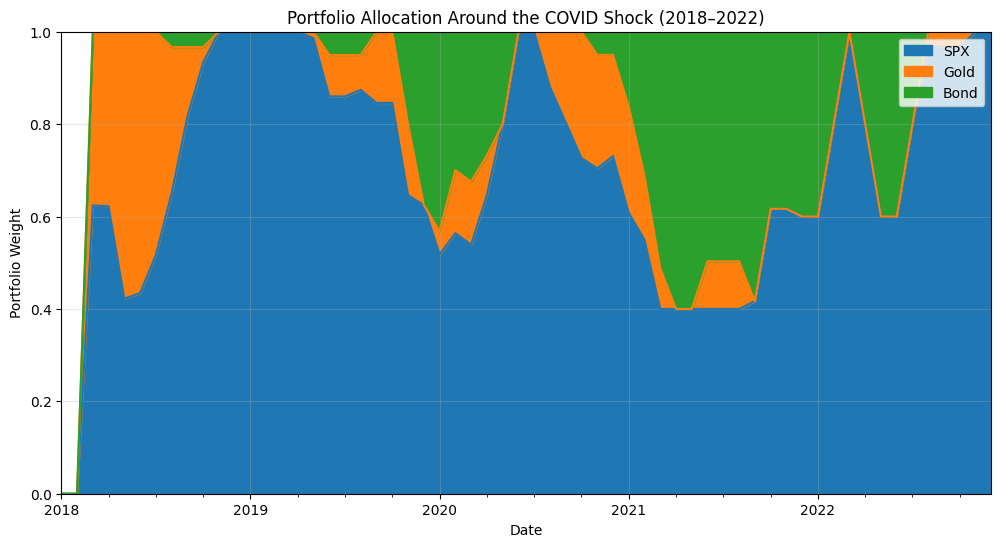

In [ ]:
# 18. ALLOCATION AROUND COVID SHOCK

weights_covid = weights_oos.loc["2018":"2022"].rolling(3).mean()

weights_covid.plot.area(figsize=(12, 6))
plt.title("Portfolio Allocation Around the COVID Shock (2018–2022)")
plt.ylabel("Portfolio Weight")
plt.xlabel("Date")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend(loc="upper right")
plt.show()

## Rolling Annualized Sharpe Ratio

The rolling Sharpe ratio shows how the strategy’s risk-adjusted performance evolves over time relative to the S&P 500.

Since the strategy operates on a 60-month training window, I wanted a shorter evaluation window for rolling Sharpe that reflects more recent performance dynamics. A 24-month window provides a good compromise between capturing short-term changes and maintaining statistical stability.

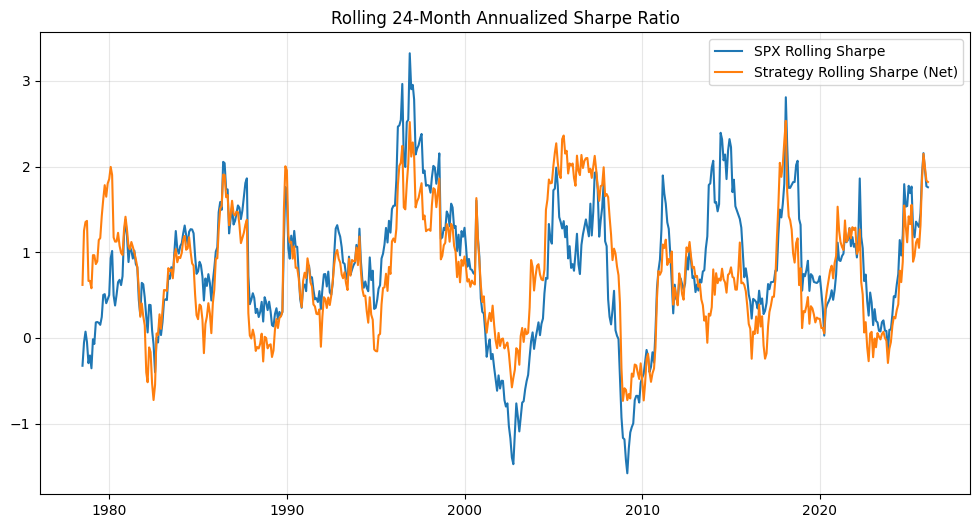

In [ ]:
# 19. ROLLING ANNUALIZED SHARPE

window = 24

rolling_sharpe_spx = (
    spx_oos.rolling(window).mean() / spx_oos.rolling(window).std()
) * np.sqrt(12)

rolling_sharpe_strat = (
    oos_net.rolling(window).mean() / oos_net.rolling(window).std()
) * np.sqrt(12)

plt.figure(figsize=(12, 6))
plt.plot(rolling_sharpe_spx, label="SPX Rolling Sharpe")
plt.plot(rolling_sharpe_strat, label="Strategy Rolling Sharpe (Net)")
plt.title("Rolling 24-Month Annualized Sharpe Ratio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Additional Observations

The strategy performs strongest in regimes where inflation risk is more prominent, particularly overheating and stagflation environments. This suggests that gold and Treasuries provide more effective hedging when inflation dynamics dominate.

Another observation is that turnover is relatively high, indicating that regime instability can lead to frequent reallocation. This highlights the trade-off between adapting quickly to macro changes and maintaining a stable, low-cost portfolio.

## Conclusion

The regime-based hedging framework improves downside protection significantly relative to an unhedged S&P 500 portfolio, reducing maximum drawdown from -52.6% to approximately -34%.

Compared to a static diversified portfolio, the strategy offers stronger drawdown control but does not outperform on all risk-adjusted metrics. In particular, the static allocation achieves a higher Sortino ratio, while the regime-based strategy provides more adaptive exposure across macro environments.

The static allocation benefits from persistent, smooth diversification without the noise introduced by monthly regime switching. Each time the strategy rebalances in response to a regime change, it incurs transaction costs and occasionally re-allocates into a suboptimal position if the regime signal is noisy. The regime strategy compensates by offering stronger drawdown control (-34.3% vs -42.4%), which matters more in tail risk scenarios.


Overall, the results highlight a key trade-off between dynamic allocation and simplicity, where more complex strategies improve capital preservation but may not always dominate simpler approaches.

## Limitations

- Macro signals are lagged approximations rather than true real-time release data  
- GDP is interpolated from quarterly data  
- Treasury returns are approximated using a constant-duration model  
- Regime sample sizes are uneven  
- The optimisation depends on sample mean and covariance estimates  
- Results are sensitive to the chosen risk-aversion parameter
- The 60% cap on gold and bond allocation is a design constraint to ensure the portfolio always maintains meaningful equity exposure; results are sensitive to this choice  

## Next Steps

- Use Treasury total return indices instead of yield approximations  
- Incorporate real-time macro release data  
- Test alternative regime definitions  
- Introduce constraints or smoothing to reduce turnover  
- Perform sensitivity analysis on the risk-aversion parameter  